# P630: Regression – Solar Power Generation

**Group Members – Group 3**

Jayshri Bhaskar Kor

Prasanna M Kulkarni

Hema Sai Reddy Anam

Yash Dilip Sonone

Banka Rama Krishna

Soniya G R

Karthik Betageri

#

## Project Overview
This project focuses on predicting solar power generation using environmental and atmospheric variables.
The prediction is performed for a 3-hour time interval using regression-based machine learning techniques.


#

## Objective
- To build a regression model for predicting solar power generation  
- To analyze how weather conditions affect energy production  
- To support energy planning and efficient utilization of solar resources


## Type of Problem
- Regression Problem  
- Target variable is continuous in nature



#

## Dataset Description
- Total Records: 2,920  
- Total Columns: 10  
- Each row represents a 3-hour time interval  
- Dataset contains historical solar power generation data along with weather conditions


#

## Input Features
The dataset includes the following environmental and atmospheric variables:
- Temperature  
- Wind characteristics  
- Humidity  
- Sky conditions  
- Atmospheric pressure  
- Other weather-related parameters


## Target Variable
- **power-generated**  
- Represents the amount of solar energy produced (in Joules) during each 3-hour interval


#

## Data Exploration and EDA

### **Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### **Load the dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving solarpowergeneration.csv to solarpowergeneration.csv


In [ ]:
# Load the dataset
df = pd.read_csv('solarpowergeneration.csv')

# Display first 5 rows
df.head()


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


#

### **Dataset Structure & Sanity Check**

In [ ]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)


Dataset Shape: (2920, 10)

Column Names:
Index(['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)', 'power-generated'],
      dtype='object')


#

### **Data Types & Missing Values Check**

In [ ]:
# Check column data types and non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [ ]:
print("\nStatistical Summary:\n")
df.describe()


Statistical Summary:



,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2919.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.261547,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


In [ ]:
# Check missing values
print("\nMissing values per column:")
df.isnull().sum()



Missing values per column:


,0
distance-to-solar-noon,0
temperature,0
wind-direction,0
wind-speed,0
sky-cover,0
visibility,0
humidity,0
average-wind-speed-(period),1
average-pressure-(period),0
power-generated,0


The dataset contains only one missing value in a numerical column.
To handle this, median imputation is used as it is robust to outliers.

The missing value in `average-wind-speed-(period)` is replaced with its median value.

#

### **Handle Missing Value**

In [ ]:
# Handle missing value using mean imputation
df['average-wind-speed-(period)'] = df['average-wind-speed-(period)'].fillna(
    df['average-wind-speed-(period)'].mean()
)

# Verify
df.isnull().sum()


,0
distance-to-solar-noon,0
temperature,0
wind-direction,0
wind-speed,0
sky-cover,0
visibility,0
humidity,0
average-wind-speed-(period),0
average-pressure-(period),0
power-generated,0


#

### **Duplicate Records Check**

In [ ]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

#

### **Target Variable Sanity Check (Numerical)**

In [ ]:
# Numerical summary of target variable
df['power-generated'].describe()


,power-generated
count,2920.000000
mean,6979.846233
std,10312.336413
min,0.000000
25%,0.000000
50%,404.000000
75%,12723.500000
max,36580.000000


#### Target Variable Analysis: Power Generated (Numerical Summary)

- Total observations: **2920**
- Minimum value is **0**, indicating no power generation during some intervals
- **25th percentile and median** are very low, showing many low-output periods
- **Mean (6979) is much higher than median (404)**, indicating a right-skewed distribution
- Maximum value reaches **36580**, showing occasional high power generation
- High standard deviation indicates **large variability** in power output

**Insight:**  
The target variable is highly skewed and unevenly distributed, which is important for
model selection, transformation techniques, and evaluation metrics.


#

### **Target Vaiable Distribution**

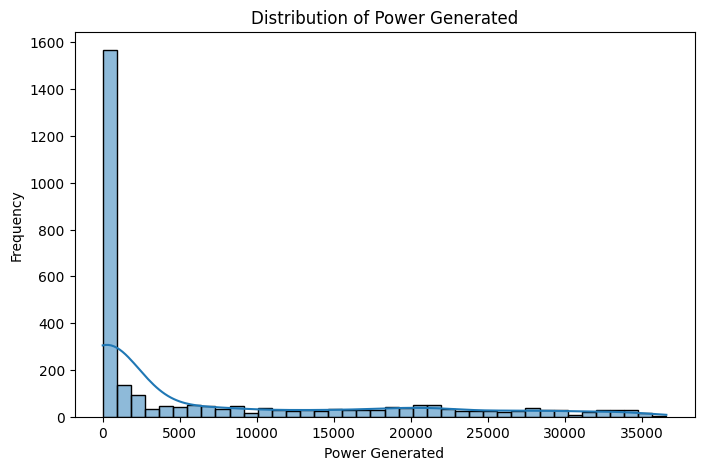

In [ ]:
# Target variable distribution with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['power-generated'], bins=40, kde=True)
plt.xlabel('Power Generated')
plt.ylabel('Frequency')
plt.title('Distribution of Power Generated')
plt.show()


##### Target Variable Distribution

- Distribution is **right-skewed**
- Most values are near **zero**
- Few intervals show **very high power generation**
- Long tail indicates **high variability**

**Insight:**  
Solar power generation is uneven and influenced by changing conditions.


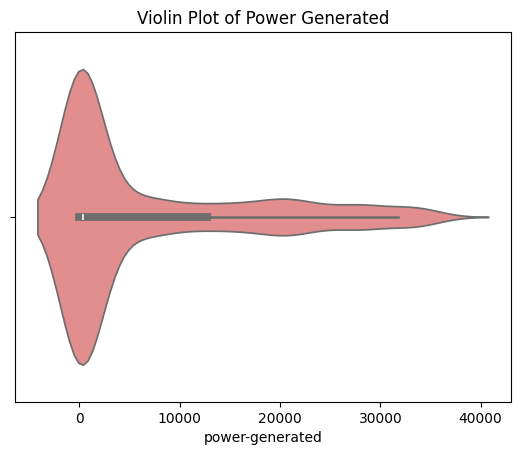

In [ ]:
# Violin plot of power-generated
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x=df['power-generated'], color='lightcoral')
plt.title('Violin Plot of Power Generated')
plt.show()


This violin plot clearly shows that most power generation values are concentrated at the lower range, with a long tail on the higher side, confirming right-skewness

#

In [ ]:
# Skewness of target variable
df['power-generated'].skew()


np.float64(1.3070350643796376)

Skewness value (~1.30) indicates that power-generated is positively skewed with a long right tail.


#

In [ ]:
# Zero vs Non-Zero power generation count
df['power-generated'].apply(lambda x: 'Zero' if x == 0 else 'Non-Zero').value_counts()


,count
power-generated,
Non-Zero,1600
Zero,1320


Out of 2920 records, 1320 intervals show zero power generation, indicating many low or no-sunlight periods.


#

### **Univariate Analysis**

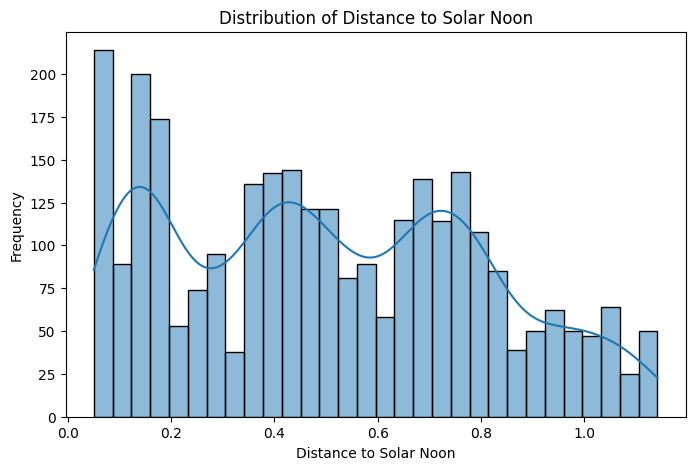

In [ ]:
# Distribution of distance-to-solar-noon
plt.figure(figsize=(8, 5))
sns.histplot(df['distance-to-solar-noon'], bins=30, kde=True)
plt.xlabel('Distance to Solar Noon')
plt.ylabel('Frequency')
plt.title('Distribution of Distance to Solar Noon')
plt.show()


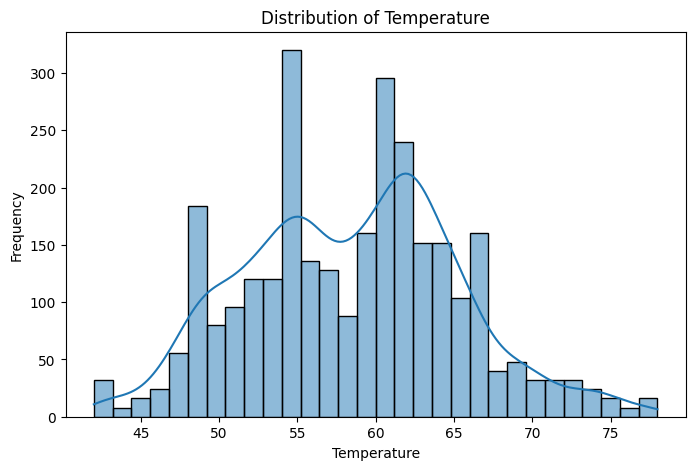

In [ ]:
# Distribution of temperature
plt.figure(figsize=(8, 5))
sns.histplot(df['temperature'], bins=30, kde=True)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.show()


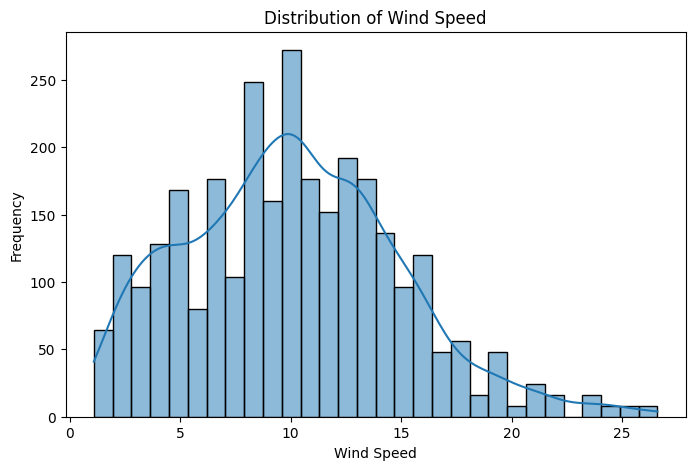

In [ ]:
# Distribution of wind-speed
plt.figure(figsize=(8, 5))
sns.histplot(df['wind-speed'], bins=30, kde=True)
plt.xlabel('Wind Speed')
plt.ylabel('Frequency')
plt.title('Distribution of Wind Speed')
plt.show()


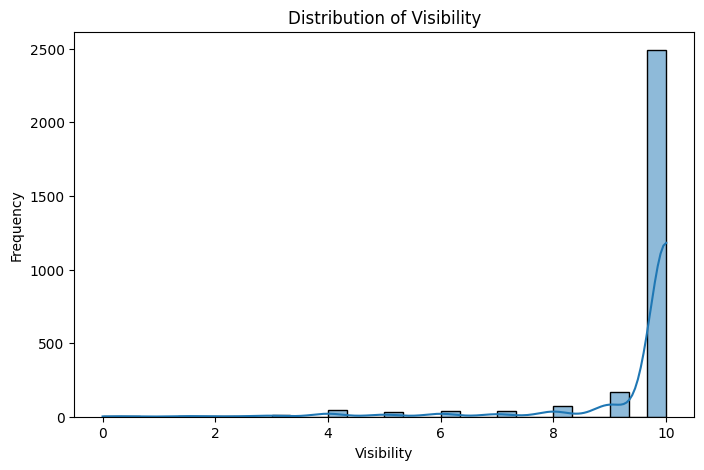

In [ ]:
# Distribution of visibility
plt.figure(figsize=(8, 5))
sns.histplot(df['visibility'], bins=30, kde=True)
plt.xlabel('Visibility')
plt.ylabel('Frequency')
plt.title('Distribution of Visibility')
plt.show()


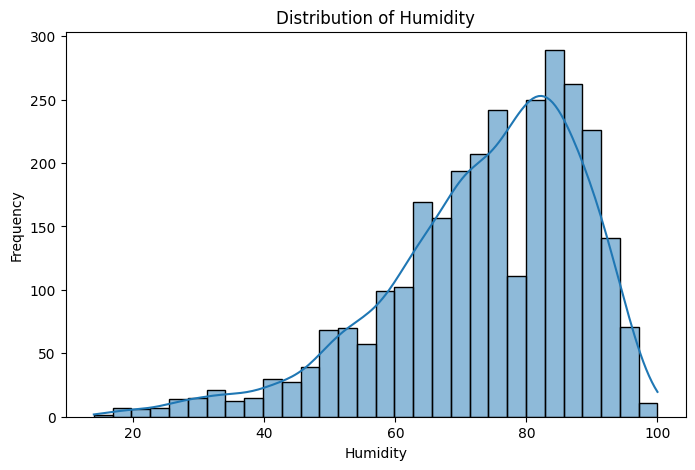

In [ ]:
# Distribution of humidity
plt.figure(figsize=(8, 5))
sns.histplot(df['humidity'], bins=30, kde=True)
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.title('Distribution of Humidity')
plt.show()


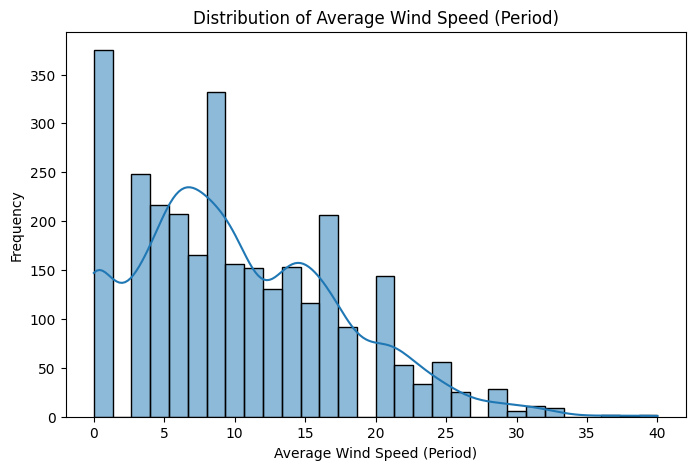

In [ ]:
# Distribution of average wind speed (period)
plt.figure(figsize=(8, 5))
sns.histplot(df['average-wind-speed-(period)'], bins=30, kde=True)
plt.xlabel('Average Wind Speed (Period)')
plt.ylabel('Frequency')
plt.title('Distribution of Average Wind Speed (Period)')
plt.show()


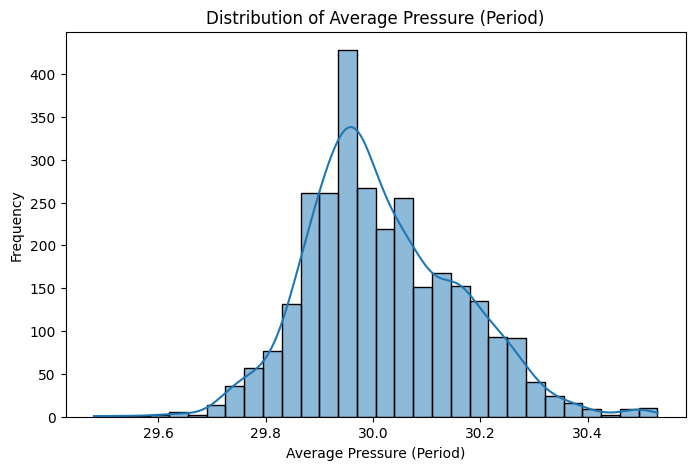

In [ ]:
# Distribution of average pressure (period)
plt.figure(figsize=(8, 5))
sns.histplot(df['average-pressure-(period)'], bins=30, kde=True)
plt.xlabel('Average Pressure (Period)')
plt.ylabel('Frequency')
plt.title('Distribution of Average Pressure (Period)')
plt.show()


##### **Univariate Distribution Summary**

- Most numerical features show **non-uniform distributions**
- Target variable (power-generated) is **highly right-skewed** with many zero values
- Distance to solar noon is well spread, reflecting different sun positions
- Temperature and wind speed show **moderate variation**
- Visibility values are concentrated at higher levels
- Humidity is mostly on the higher side
- Average wind speed shows right skewness
- Atmospheric pressure is **normally distributed**
- Sky cover values are distributed across all categories

**Insight:**  
The dataset contains varied distributions, skewness, and extreme values,
highlighting the need for proper preprocessing and feature handling.


#

### **Outlier Detection Using Boxplots**

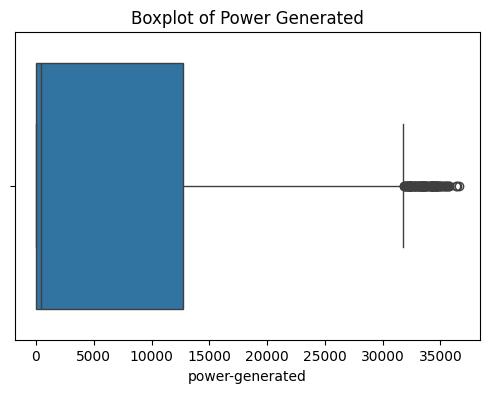

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['power-generated'])
plt.title('Boxplot of Power Generated')
plt.show()


##### Boxplot of Power Generated

- Power generation is highly right-skewed
- Majority of values are near zero
- Several high-value outliers are present

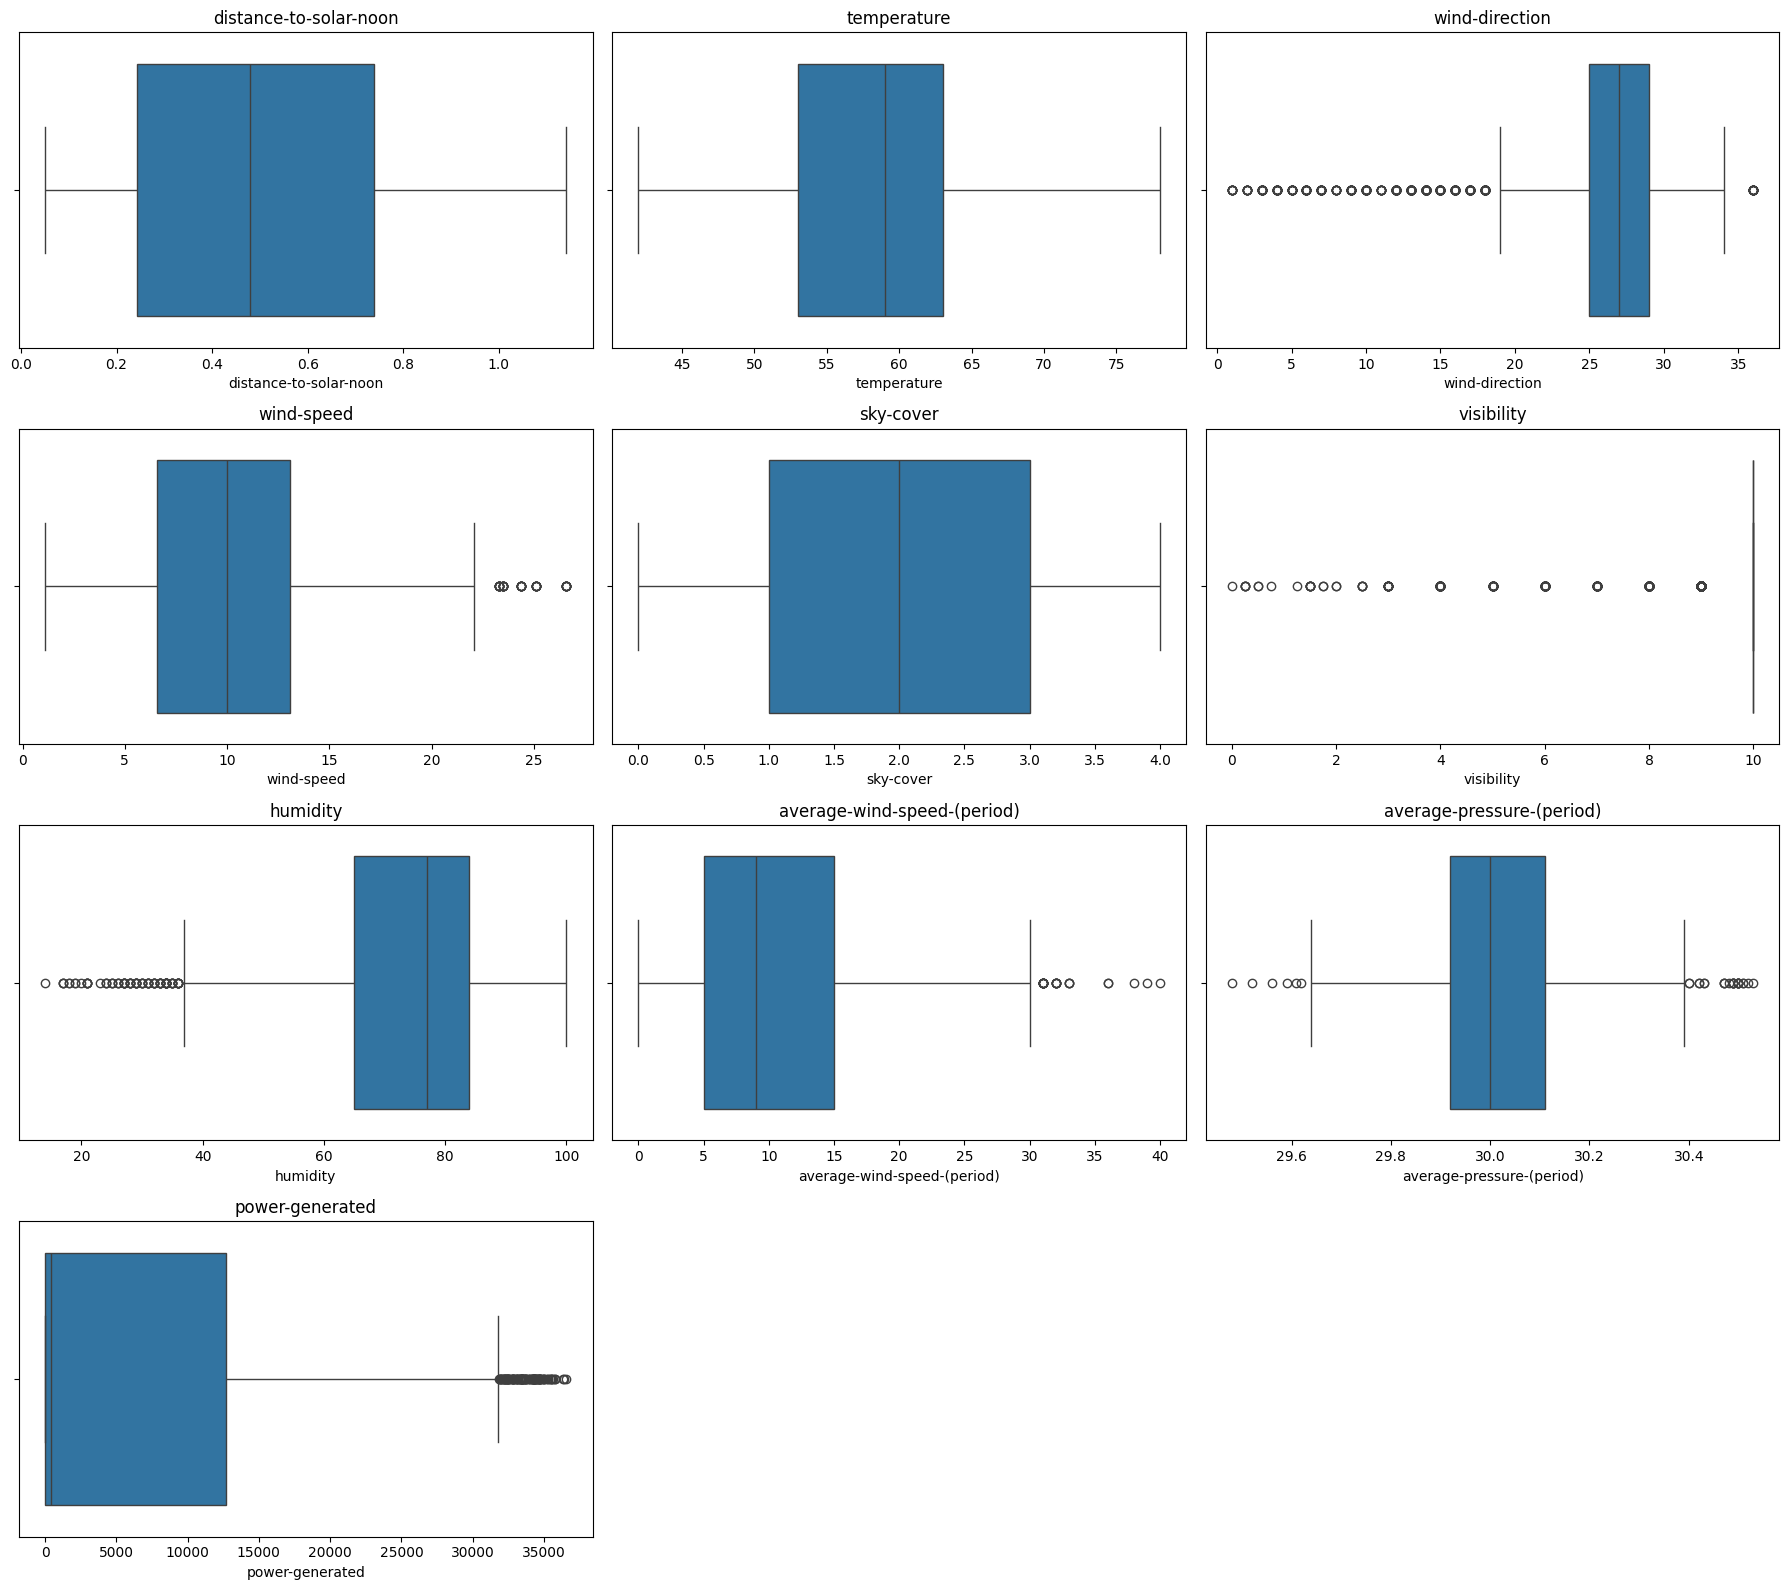

In [ ]:
# Boxplots of all features
cols = df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

##### Boxplot Analysis Summary

- Most features show moderate spread with some outliers
- Wind and humidity variables contain noticeable outliers
- Atmospheric pressure is tightly distributed
- Power generated is highly right-skewed with many outliers

**Insight:**  
Outliers reflect natural environmental variability and are retained for modeling.


In [ ]:
# IQR based outlier count for all numerical features

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier_count = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()

outlier_count_df = outlier_count.to_frame(name='Outlier Count')
outlier_count_df


,Outlier Count
distance-to-solar-noon,0
temperature,0
wind-direction,528
wind-speed,40
sky-cover,0
visibility,429
humidity,83
average-wind-speed-(period),25
average-pressure-(period),31
power-generated,107


#

### Count Plot (Sky Cover)

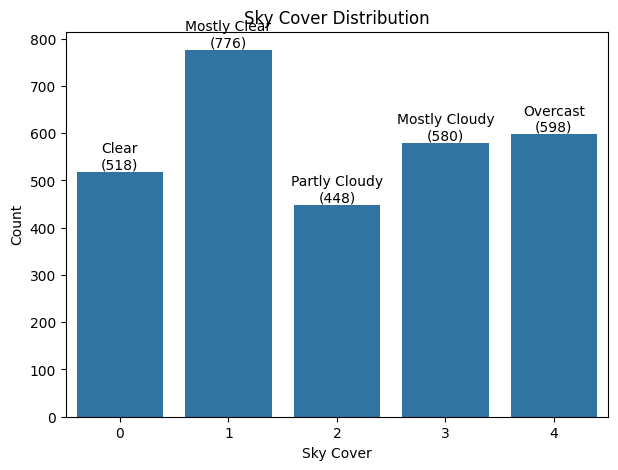

In [ ]:
# Mapping for sky_cover categories
sky_labels = {
    0: 'Clear',
    1: 'Mostly Clear',
    2: 'Partly Cloudy',
    3: 'Mostly Cloudy',
    4: 'Overcast'
}

plt.figure(figsize=(7,5))
ax = sns.countplot(x='sky-cover', data=df)

plt.title('Sky Cover Distribution')
plt.xlabel('Sky Cover')
plt.ylabel('Count')

# Add category name + count on each bar
for p in ax.patches:
    category = int(p.get_x() + p.get_width() / 2)
    count = int(p.get_height())
    label = sky_labels.get(category, '')

    ax.annotate(
        f'{label}\n({count})',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()


##### Sky Cover Distribution

- Mostly clear sky conditions occur most frequently
- Partly cloudy conditions have the lowest count
- Cloudy and overcast conditions are also common


#

## Neumerical Feature Distribution

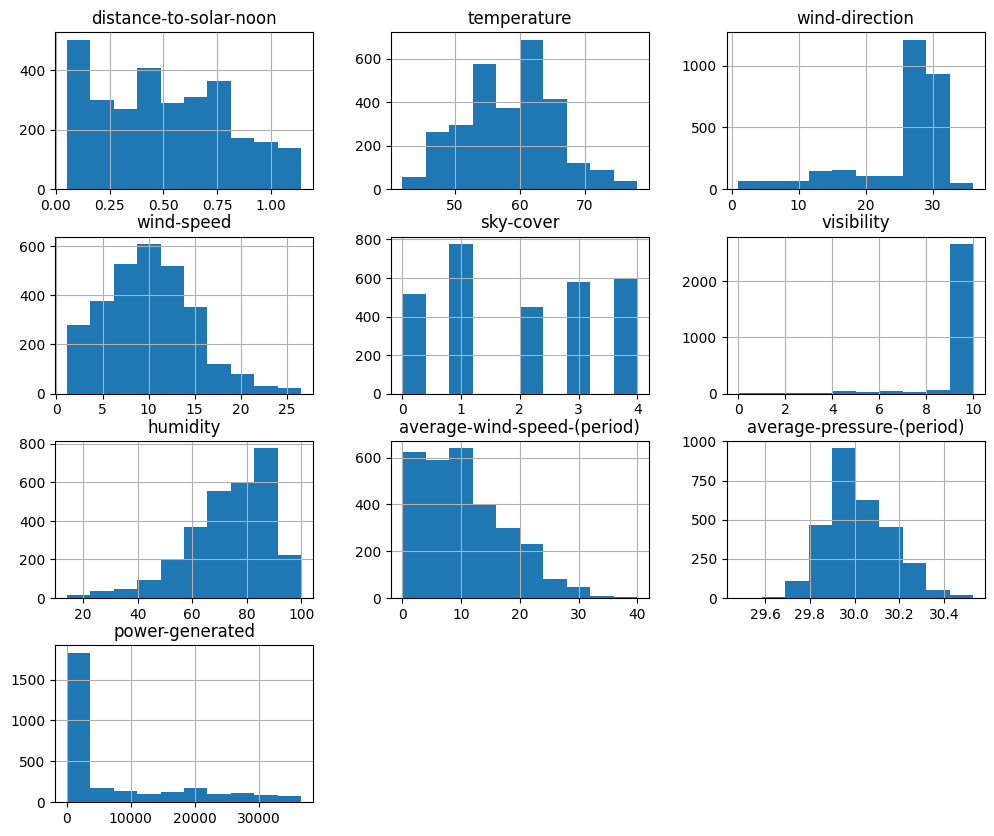

In [ ]:
df.hist(figsize=(12,10))
plt.show()

#

### **Bivariate Analysis**

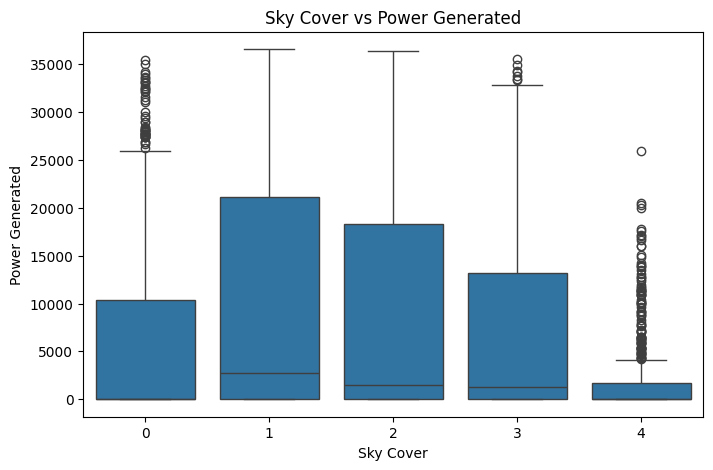

In [ ]:
# Sky Cover vs Power Generated
plt.figure(figsize=(8, 5))
sns.boxplot(x='sky-cover', y='power-generated', data=df)
plt.xlabel('Sky Cover')
plt.ylabel('Power Generated')
plt.title('Sky Cover vs Power Generated')
plt.show()


- Clear skies show **higher power generation**
- Power output **decreases as sky cover increases**
- Overcast conditions mostly result in **low power**
- Presence of outliers indicates **variable sunlight conditions**

**Insight:**  
Sky cover has a strong negative impact on solar power generation.

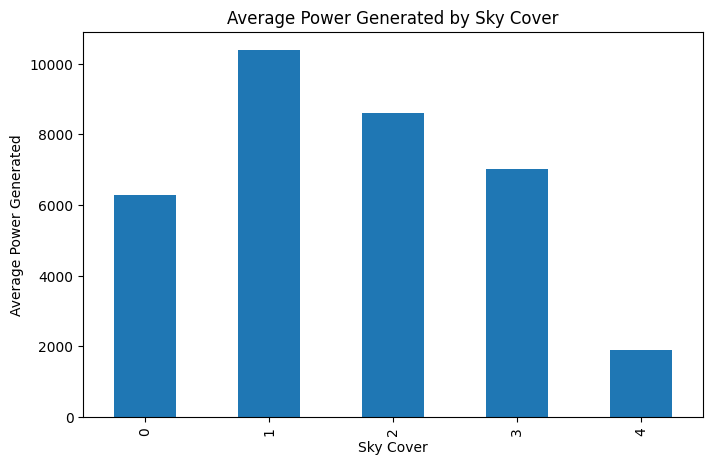

In [ ]:
# Sky Cover vs Average Power Generated
avg_power_by_sky = df.groupby('sky-cover')['power-generated'].mean()

plt.figure(figsize=(8, 5))
avg_power_by_sky.plot(kind='bar')
plt.xlabel('Sky Cover')
plt.ylabel('Average Power Generated')
plt.title('Average Power Generated by Sky Cover')
plt.show()


Average power generation decreases steadily as sky cover increases.


#

### **Relationship: Distance to Solar Noon vs Power Generated**

In [ ]:
# Correlation between distance to solar noon and power generated
df['distance-to-solar-noon'].corr(df['power-generated'])


np.float64(-0.7466813768914985)

##### Correlation Result: Distance to Solar Noon vs Power Generated

- The correlation value is **-0.75**, indicating a strong negative relationship.
- As the distance to solar noon decreases, power generation increases.
- This confirms that sun position is a key factor affecting solar power output.
- The strong correlation suggests this feature will be highly important for modeling.


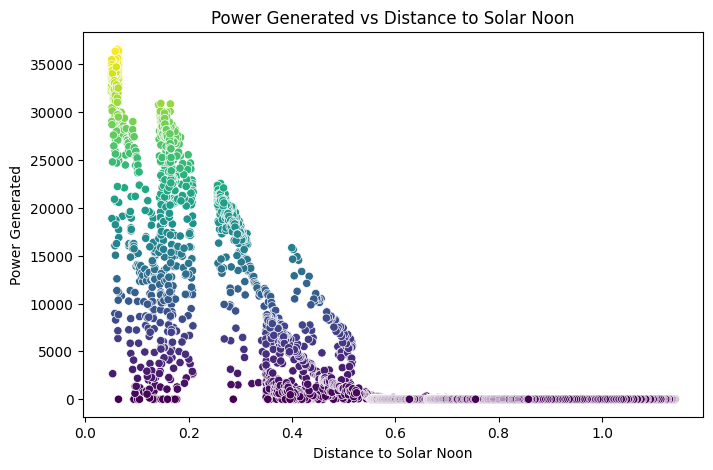

In [ ]:
# Distance to Solar Noon vs Power Generated (colored scatter)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='distance-to-solar-noon',
    y='power-generated',
    data=df,
    hue='power-generated',
    palette='viridis',
    legend=False
)
plt.xlabel('Distance to Solar Noon')
plt.ylabel('Power Generated')
plt.title('Power Generated vs Distance to Solar Noon')
plt.show()


##### Observation: Distance to Solar Noon vs Power Generated

- Power generation is **highest near solar noon**
- Power **decreases sharply** as distance increases
- High values are concentrated **close to solar noon**
- Farther intervals show **near-zero power**


#

### **Temperature vs Power Generated**

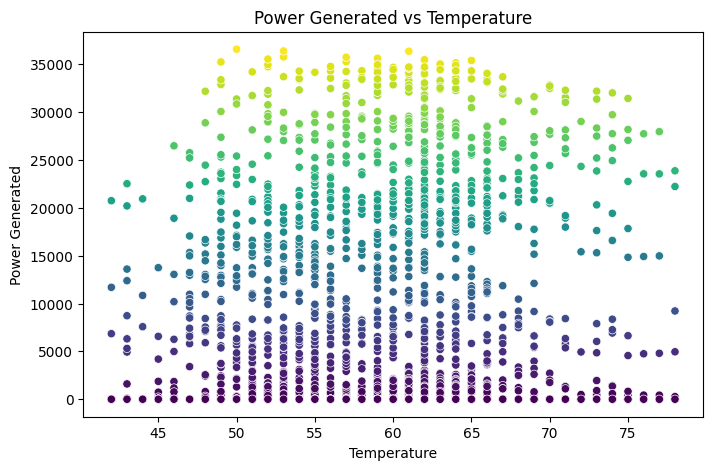

In [ ]:
# Temperature vs Power Generated
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='temperature',
    y='power-generated',
    data=df,
    hue='power-generated',
    palette='viridis',
    legend=False
)
plt.xlabel('Temperature')
plt.ylabel('Power Generated')
plt.title('Power Generated vs Temperature')
plt.show()


##### Observation: Temperature vs Power Generated

- Power varies across all temperature values
- Higher output occurs at **moderate temperatures**
- No strong linear relationship is observed
- Temperature has a **secondary impact** compared to sun position and sky cover


### **Humidity vs Power Generated**

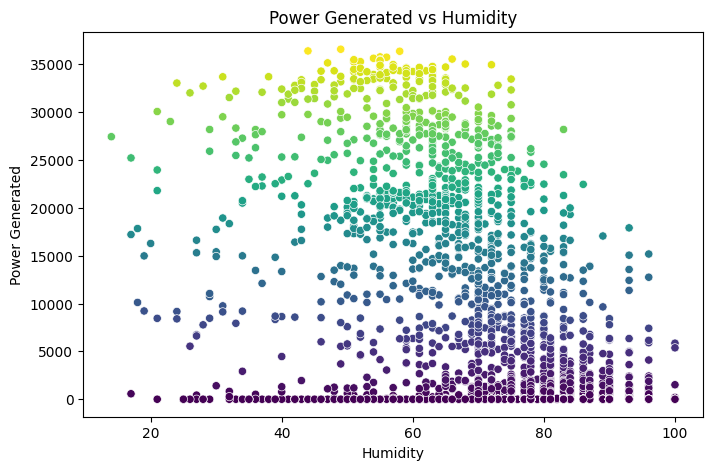

In [ ]:
# Humidity vs Power Generated
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='humidity',
    y='power-generated',
    data=df,
    hue='power-generated',
    palette='viridis',
    legend=False
)
plt.xlabel('Humidity')
plt.ylabel('Power Generated')
plt.title('Power Generated vs Humidity')
plt.show()


##### Observation: Humidity vs Power Generated

- Higher power occurs at **moderate humidity**
- Power **decreases as humidity increases**
- Very high humidity shows **low or near-zero output**
- Humidity has a **negative impact** on solar power generation


#

### **Wind Speed vs Power Generated**

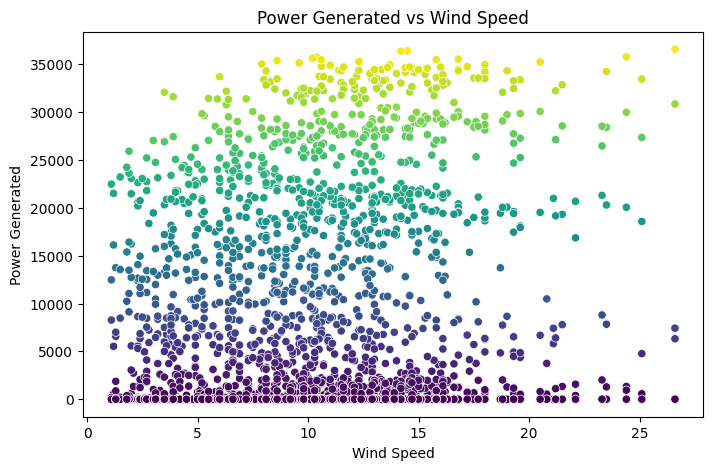

In [ ]:
# Wind Speed vs Power Generated
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='wind-speed',
    y='power-generated',
    data=df,
    hue='power-generated',
    palette='viridis',
    legend=False
)
plt.xlabel('Wind Speed')
plt.ylabel('Power Generated')
plt.title('Power Generated vs Wind Speed')
plt.show()


##### Observation: Wind Speed vs Power Generated

- Power is spread across all wind speeds
- No clear trend between wind speed and power
- High and low values occur at similar speeds
- Wind speed has a **weak influence** on power generation


#

### **Visibility vs Power Generated**

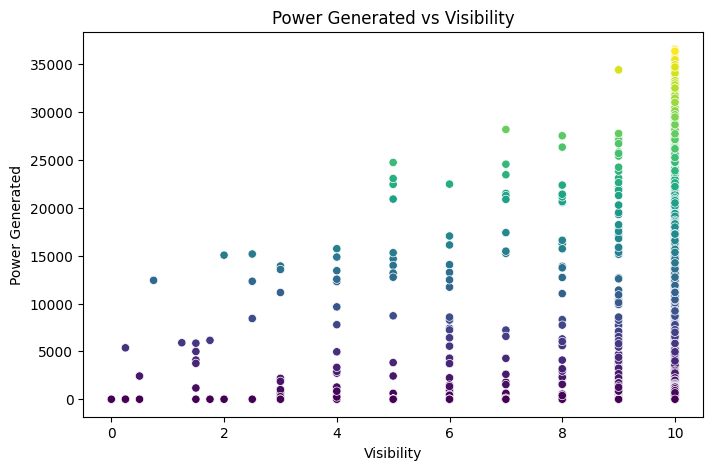

In [ ]:
# Visibility vs Power Generated (Bivariate Analysis)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='visibility',
    y='power-generated',
    data=df,
    hue='power-generated',
    palette='viridis',
    legend=False
)
plt.xlabel('Visibility')
plt.ylabel('Power Generated')
plt.title('Power Generated vs Visibility')
plt.show()


##### Observation: Visibility vs Power Generated

- Higher visibility generally shows **higher power generation**
- Low visibility is associated with **low or zero power**
- Relationship is positive but **not strictly linear**
- Visibility has a **moderate influence** on power output


#

### **Average Wind Speed (Period) vs Power Generated**

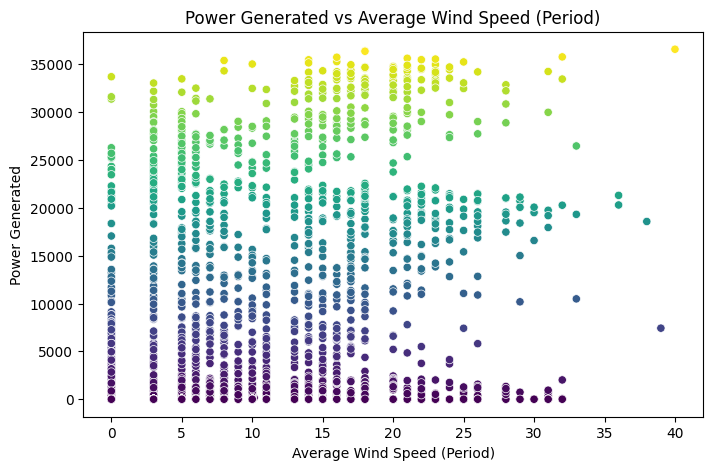

In [ ]:
# Average Wind Speed (Period) vs Power Generated
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='average-wind-speed-(period)',
    y='power-generated',
    data=df,
    hue='power-generated',
    palette='viridis',
    legend=False
)
plt.xlabel('Average Wind Speed (Period)')
plt.ylabel('Power Generated')
plt.title('Power Generated vs Average Wind Speed (Period)')
plt.show()


##### Observation: Average Wind Speed (Period) vs Power Generated

- Power values are spread across different wind speeds
- No clear linear relationship is visible
- High and low power values occur at similar speeds
- Average wind speed has a **weak influence** on power generation


#

### **Average Pressure (Period) vs Power Generated**

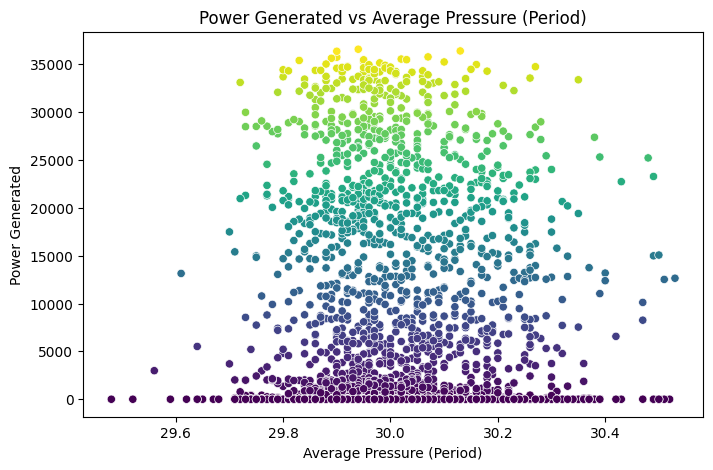

In [ ]:
# Average Pressure (Period) vs Power Generated
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='average-pressure-(period)',
    y='power-generated',
    data=df,
    hue='power-generated',
    palette='viridis',
    legend=False
)
plt.xlabel('Average Pressure (Period)')
plt.ylabel('Power Generated')
plt.title('Power Generated vs Average Pressure (Period)')
plt.show()


##### Observation: Average Pressure (Period) vs Power Generated

- Power values are widely scattered across pressure levels
- No clear linear relationship is observed
- Similar power values occur at different pressures
- Average pressure has a **weak influence** on power generation


#

### **Multivariate Analysis**

#### Correlation Heatmap

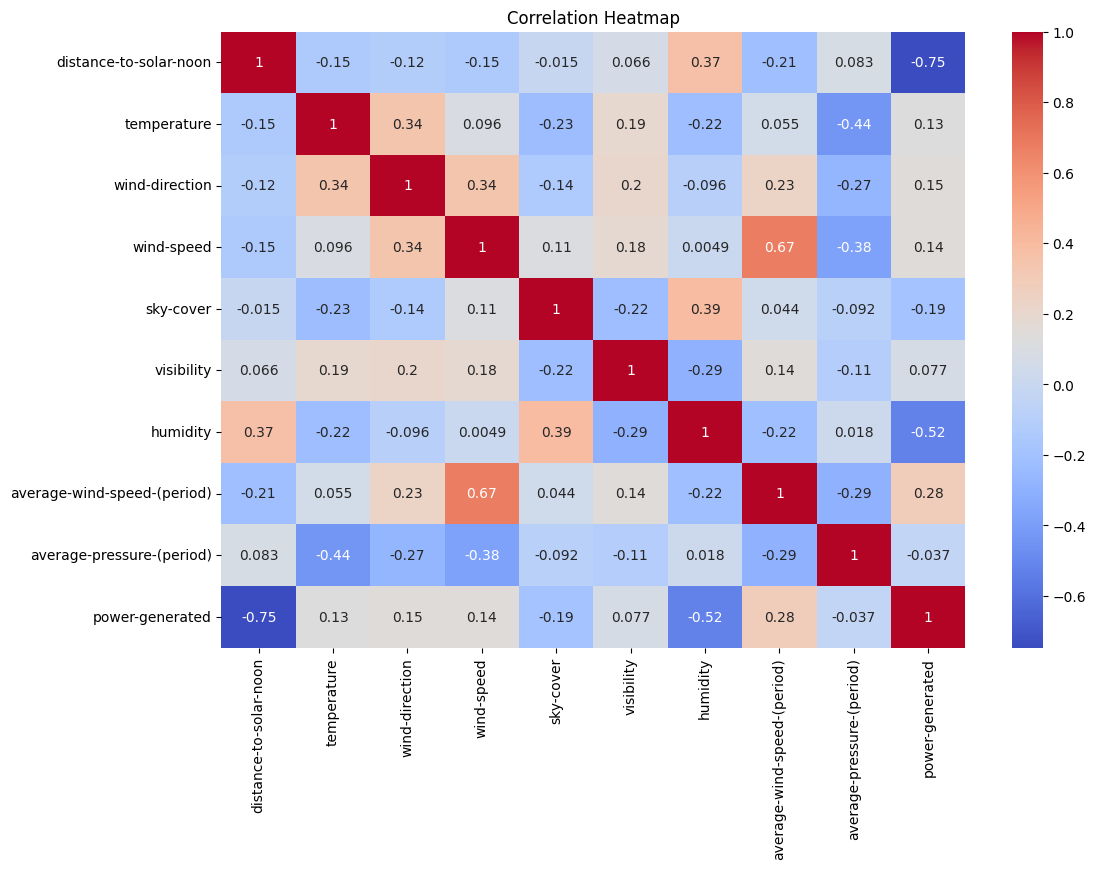

In [ ]:
# Correlation Heatmap (Multivariate Analysis)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


##### Correlation Heatmap – Key Insights

- **Distance to solar noon** has a strong negative correlation with power generation
- **Humidity** also shows a moderate negative correlation with power
- **Sky cover** has a negative relationship with power output
- **Temperature, wind speed, and visibility** show weak correlations
- Average pressure has **almost no impact** on power generation

**Insight:**  
Solar power generation is primarily driven by sun position and sky conditions,
while other weather variables have limited influence.


### Multicollinearity Observation

From the correlation analysis, a strong positive correlation is observed
between wind-speed and average-wind-speed-(period).

This indicates the presence of multicollinearity among some input features,
which may reduce the effectiveness of linear regression models.
Tree-based models are less affected by this issue.


#

### Exploratory Data Analysis (EDA) Summary

- The dataset contains 2,920 records with no major missing values.
- Solar power generation shows a highly right-skewed distribution with many zero values.
- Distance to solar noon has a strong negative relationship with power generation.
- Sky cover and humidity negatively impact solar power output.
- Temperature, wind speed, visibility, and pressure show weaker relationships.
- Outliers are present across multiple features due to natural weather variations.
- Overall, sun position and sky conditions are the most influential factors.



#

## FEATURE ENGINEERING

### Target Variable Transformation

In [ ]:
# Log transformation of target variable (analysis purpose)
df['power_generated_log'] = np.log1p(df['power-generated'])

# Compare skewness before and after transformation
print("Original target skewness:", df['power-generated'].skew())
print("Log-transformed target skewness:", df['power_generated_log'].skew())


Original target skewness: 1.3070350643796376
Log-transformed target skewness: 0.002995180610538875


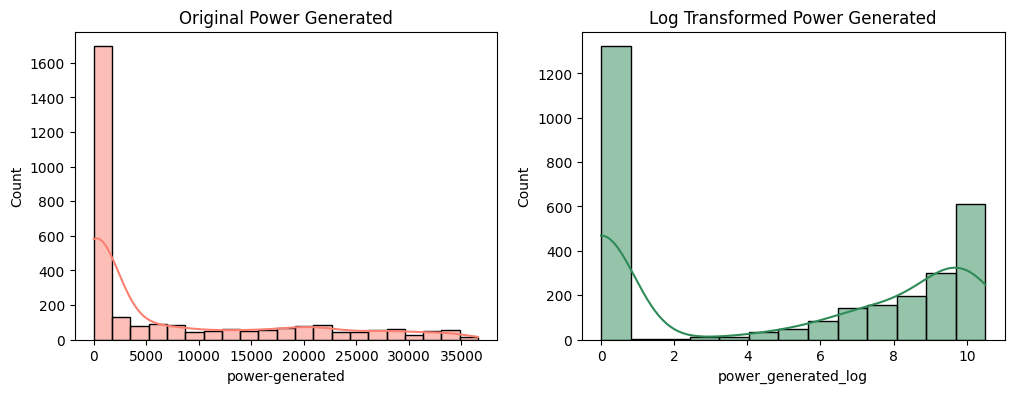

In [ ]:
df['power_generated_log'] = np.log1p(df['power-generated'])

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['power-generated'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Original Power Generated')

sns.histplot(df['power_generated_log'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Log Transformed Power Generated')

plt.show()


##### Target Transformation Decision

Log transformation reduces target skewness from **1.30 to ~0**, making the distribution more normal.
Hence, the log-transformed target is suitable for regression modeling.

#

### Final Feature Set Preparation

In [ ]:
# Define features and target for modeling
X = df.drop(columns=['power-generated', 'power_generated_log'])
y = df['power_generated_log']

# Check shapes
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (2920, 9)
Target vector shape: (2920,)


#

### Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2336, 9)
X_test shape: (584, 9)
y_train shape: (2336,)
y_test shape: (584,)


##### Train–Test Split Result

- Training set contains **2336 samples with 9 features**
- Testing set contains **584 samples with 9 features**
- Target variable is split consistently with the features

#

## Feature Scaling – Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Check shapes after scaling
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)



X_train_scaled shape: (2336, 9)
X_test_scaled shape: (584, 9)


### Feature Scaling Result

- Training data is scaled to **2336 samples with 9 features**
- Testing data is scaled to **584 samples with 9 features**
- Same scaler is applied to both sets to avoid data leakage

#

# MODEL BUILDING

## Model 1: Linear Regression

Linear Regression is used as a baseline model to understand how well
a simple linear relationship can predict solar power generation.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize Linear Regression model
lr = LinearRegression()

In [ ]:
# Train model on scaled training data
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Predictions on test data
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Performance")
print(f"R² Score : {r2_lr:.3f}")
print(f"RMSE     : {rmse_lr:.2f}")

Linear Regression Performance
R² Score : 0.723
RMSE     : 2.35


**Linear Regression – Performance Summary**

- R² score of **0.72** indicates a reasonable baseline fit
- RMSE of **2.35** shows average prediction error on the log-transformed scale

**Insight:**  
Linear Regression provides a baseline performance but may not fully capture
non-linear relationships in the data.

#

## Model 2: Ridge Regression

Ridge Regression applies L2 regularization to reduce overfitting by
penalizing large coefficients while keeping all features in the model.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize Ridge model
ridge = Ridge(alpha=1.0)

In [ ]:
# Train on scaled data
ridge.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
# Predict on test data
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluation
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge Regression Performance")
print(f"R² Score : {r2_ridge:.3f}")
print(f"RMSE     : {rmse_ridge:.2f}")

Ridge Regression Performance
R² Score : 0.723
RMSE     : 2.35


**Ridge Regression – Performance Summary**

- R² score of **0.72**, similar to Linear Regression
- RMSE of **2.35** indicates comparable prediction error

**Insight:**  
Ridge regularization does not improve performance over the baseline linear model.


#

## Model 3: Lasso Regression

Lasso Regression applies L1 regularization, which can shrink some coefficients
to zero and perform implicit feature selection.


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize Lasso model
lasso = Lasso(alpha=0.001, max_iter=10000)

In [ ]:
# Train on scaled data
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.001, max_iter=10000)

In [ ]:
# Predict on test data
y_pred_lasso = lasso.predict(X_test_scaled)

# Evaluation
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression Performance")
print(f"R² Score : {r2_lasso:.3f}")
print(f"RMSE     : {rmse_lasso:.2f}")

Lasso Regression Performance
R² Score : 0.723
RMSE     : 2.35


**Lasso Regression – Performance Summary**

- R² score of **0.72**, similar to Linear and Ridge Regression
- RMSE of **2.35** indicates comparable prediction error

**Insight:**  
Lasso regularization does not provide performance improvement over other linear models.


#

## Model 4: Decision Tree Regression

Decision Tree Regression is a non-linear model that captures complex
interactions between features without assuming linear relationships.


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize Decision Tree model
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)


In [ ]:
# Train model
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [ ]:
# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluation
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree Regression Performance")
print(f"R² Score : {r2_dt:.3f}")
print(f"RMSE     : {rmse_dt:.2f}")

Decision Tree Regression Performance
R² Score : 0.831
RMSE     : 1.84


**Decision Tree Regression – Performance Summary**

- R² score of **0.83** indicates a strong model fit
- RMSE of **1.84** shows a significant reduction in prediction error

**Insight:**  
Decision Tree effectively captures non-linear relationships and performs
much better than linear models.


#

## Model 5: Random Forest Regression

Random Forest is an ensemble-based non-linear model that combines multiple
decision trees to improve prediction accuracy and reduce overfitting.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize Random Forest model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


In [ ]:
# Train model
rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Regression Performance")
print(f"R² Score : {r2_rf:.3f}")
print(f"RMSE     : {rmse_rf:.2f}")

Random Forest Regression Performance
R² Score : 0.905
RMSE     : 1.38


**Random Forest Regression – Performance Summary**

- R² score of **0.91** indicates very strong predictive performance
- RMSE of **1.38** shows a substantial reduction in prediction error

**Insight:**  
Random Forest captures complex non-linear patterns and significantly
outperforms linear and single-tree models.


#

## Model 6: Gradient Boosting Regression

Gradient Boosting is an ensemble technique that builds models sequentially
to correct previous errors, making it effective for complex non-linear data.


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize Gradient Boosting model
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [ ]:
# Train model
gbr.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [ ]:
# Predictions
y_pred_gbr = gbr.predict(X_test)

# Evaluation
r2_gbr = r2_score(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print("Gradient Boosting Regression Performance")
print(f"R² Score : {r2_gbr:.3f}")
print(f"RMSE     : {rmse_gbr:.2f}")

Gradient Boosting Regression Performance
R² Score : 0.893
RMSE     : 1.46


**Gradient Boosting Regression – Performance Summary**

- R² score of **0.89** indicates very strong predictive accuracy
- RMSE of **1.46** shows low prediction error

**Insight:**  
Gradient Boosting effectively models complex non-linear relationships and
performs competitively with Random Forest.

#

## Model Performance Comparison

All regression models are compared using the same evaluation metrics
to identify the best-performing models.


In [ ]:
import pandas as pd

# Create comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree Regression",
        "Random Forest Regression",
        "Gradient Boosting Regression"
    ],
    "R² Score": [
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_dt,
        r2_rf,
        r2_gbr
    ],
    "RMSE": [
        rmse_lr,
        rmse_ridge,
        rmse_lasso,
        rmse_dt,
        rmse_rf,
        rmse_gbr
    ]
})

model_comparison


,Model,R² Score,RMSE
0,Linear Regression,0.723185,2.351970
1,Ridge Regression,0.723166,2.352053
2,Lasso Regression,0.723289,2.351529
3,Decision Tree Regression,0.831453,1.835260
4,Random Forest Regression,0.905125,1.376934
5,Gradient Boosting Regression,0.892784,1.463751


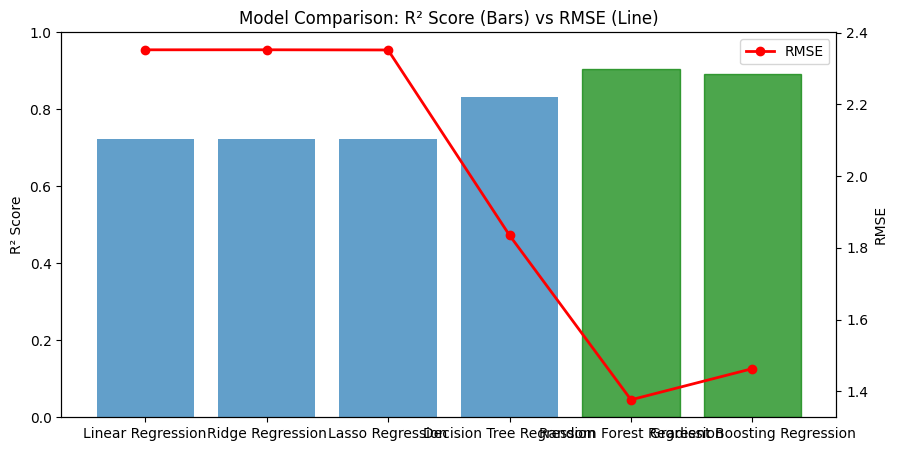

In [ ]:
import matplotlib.pyplot as plt

models = model_comparison['Model']
r2 = model_comparison['R² Score']
rmse = model_comparison['RMSE']

fig, ax1 = plt.subplots(figsize=(10,5))

# Bar chart for R²
bars = ax1.bar(models, r2, alpha=0.7)
ax1.set_ylabel('R² Score')
ax1.set_ylim(0,1)

# Highlight top 2 R² models
top2 = r2.nlargest(2).index
for i in top2:
    bars[i].set_color('green')

# Line plot for RMSE
ax2 = ax1.twinx()
ax2.plot(models, rmse, marker='o', color='red', linewidth=2, label='RMSE')
ax2.set_ylabel('RMSE')

# Title
plt.title('Model Comparison: R² Score (Bars) vs RMSE (Line)')
plt.xticks(rotation=30)

# Legend
ax2.legend(loc='upper right')

plt.show()


#### Model Comparison – Key Results

- Linear models (Linear, Ridge, Lasso) show similar performance and act as baselines
- Decision Tree improves performance by capturing non-linear patterns
- Random Forest achieves the highest R² (**0.91**) with the lowest RMSE (**1.38**)
- Gradient Boosting also performs strongly but slightly below Random Forest

**Conclusion:**  
Random Forest and Gradient Boosting are selected as the top two models
for further analysis and tuning.


#

## Hyperparameter Tuning : Random Forest Regression

Hyperparameter tuning is performed to improve model performance
by finding the optimal combination of model parameters.


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameter grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [ ]:
# Base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# GridSearch
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [ ]:
# Fit
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
# Best model
best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:", rf_grid.best_params_)


Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


#

### Evaluate Tuned Random Forest

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predictions with tuned Random Forest
y_pred_best_rf = best_rf.predict(X_test)

# Evaluation
r2_best_rf = r2_score(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

print("Tuned Random Forest Performance")
print(f"R² Score : {r2_best_rf:.3f}")
print(f"RMSE     : {rmse_best_rf:.2f}")


Tuned Random Forest Performance
R² Score : 0.900
RMSE     : 1.41


### Tuned Random Forest : Performance Summary

- R² score of **0.90** indicates strong generalization performance
- RMSE of **1.41** shows low prediction error after tuning

**Insight:**  
Hyperparameter tuning slightly improves model stability while maintaining
high predictive accuracy.


#

## Hyperparameter Tuning – Gradient Boosting Regression

Gradient Boosting hyperparameters are tuned to improve predictive accuracy
by optimizing learning rate, tree depth, and number of estimators.


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Parameter grid for Gradient Boosting
gbr_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

In [ ]:
# Base model
gbr_base = GradientBoostingRegressor(random_state=42)

# GridSearch
gbr_grid = GridSearchCV(
    estimator=gbr_base,
    param_grid=gbr_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [ ]:
# Fit
gbr_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [2, 3],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
# Best model
best_gbr = gbr_grid.best_estimator_

print("Best Gradient Boosting Parameters:", gbr_grid.best_params_)

Best Gradient Boosting Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


#

### Evaluate Tuned Gradient Boosting

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predictions with tuned Gradient Boosting
y_pred_best_gbr = best_gbr.predict(X_test)

# Evaluation
r2_best_gbr = r2_score(y_test, y_pred_best_gbr)
rmse_best_gbr = np.sqrt(mean_squared_error(y_test, y_pred_best_gbr))

print("Tuned Gradient Boosting Performance")
print(f"R² Score : {r2_best_gbr:.3f}")
print(f"RMSE     : {rmse_best_gbr:.2f}")


Tuned Gradient Boosting Performance
R² Score : 0.889
RMSE     : 1.49


#### Tuned Gradient Boosting – Performance Summary

- R² score of **0.89** indicates strong predictive performance
- RMSE of **1.49** shows low prediction error after tuning

**Insight:**  
Hyperparameter tuning improves model stability, though performance remains
slightly lower than the tuned Random Forest model.


#

## Final Model Selection

Both Random Forest and Gradient Boosting models were tuned using
GridSearchCV. After tuning, Random Forest achieved the highest R² score
(**0.90**) and the lowest RMSE (**1.41**).

Therefore, **Random Forest Regression** is selected as the final model
for predicting solar power generation.


#

## Deployment

In [ ]:
import joblib

joblib.dump(best_rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']